# Homework06
## Sofía

Exercises to practice pandas, data analysis and regression

## Goals

- Understand the effects of pre-processing data
- Get familiar with the ML flow: encode -> normalize -> train -> evaluate
- Understand the difference between regression and classification tasks
- Build intuition for different regression models

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [9]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor

from data_utils import object_from_json_url
from data_utils import regression_error

### Load Dataset

Let's load up the full [ANSUR](https://www.openlab.psu.edu/ansur2/) dataset that we looked at briefly in [Week 02](https://github.com/DM-GY-9103-2024F-H/WK02).

This is the dataset that has anthropometric information about U.S. Army personnel.

#### WARNING

Like we mentioned in class, this dataset is being used for these exercises due to the level of detail in the dataset and the rigorous process that was used in collecting the data.

This is a very specific dataset and should not be used to draw general conclusions about people, bodies, or anything else that is not related to the distribution of physical features of U.S. Army personnel.

In [11]:
# Load Dataset
ANSUR_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur.json"
ansur_data = object_from_json_url(ANSUR_FILE)

# Look at first 2 records
ansur_data[:2]

[{'age': 18,
  'gender': 'F',
  'height': 66,
  'weight': 135,
  'span': 1699,
  'stature': 1645,
  'ear': {'breadth': 30, 'length': 61, 'protrusion': 20},
  'foot': {'breadth': 97, 'length': 243},
  'hand': {'breadth': 78, 'length': 182, 'palm': 108},
  'head': {'height': 243, 'circumference': 557}},
 {'age': 30,
  'gender': 'M',
  'height': 68,
  'weight': 207,
  'span': 1749,
  'stature': 1715,
  'ear': {'breadth': 35, 'length': 63, 'protrusion': 17},
  'foot': {'breadth': 100, 'length': 252},
  'hand': {'breadth': 87, 'length': 184, 'palm': 114},
  'head': {'height': 238, 'circumference': 560}}]

#### Nested data

This is that *nested* dataset from Week 02.

# 🤔

Let's load it into a `DataFrame` to see what happens.

In [12]:
# Read into DataFrame
ansur_df = pd.DataFrame.from_records(ansur_data)
ansur_df.head()

,age,gender,height,weight,span,stature,ear,foot,hand,head
0,18,F,66,135,1699,1645,"{'breadth': 30, 'length': 61, 'protrusion': 20}","{'breadth': 97, 'length': 243}","{'breadth': 78, 'length': 182, 'palm': 108}","{'height': 243, 'circumference': 557}"
1,30,M,68,207,1749,1715,"{'breadth': 35, 'length': 63, 'protrusion': 17}","{'breadth': 100, 'length': 252}","{'breadth': 87, 'length': 184, 'palm': 114}","{'height': 238, 'circumference': 560}"
2,27,M,67,121,1684,1657,"{'breadth': 36, 'length': 59, 'protrusion': 24}","{'breadth': 92, 'length': 251}","{'breadth': 84, 'length': 180, 'palm': 103}","{'height': 239, 'circumference': 516}"
3,20,M,73,185,1878,1828,"{'breadth': 36, 'length': 60, 'protrusion': 21}","{'breadth': 104, 'length': 280}","{'breadth': 95, 'length': 201, 'palm': 124}","{'height': 270, 'circumference': 582}"
4,33,M,76,150,1977,1883,"{'breadth': 39, 'length': 65, 'protrusion': 27}","{'breadth': 101, 'length': 271}","{'breadth': 90, 'length': 194, 'palm': 113}","{'height': 254, 'circumference': 559}"



# 😓🙄

That didn't work too well. We ended up with objects in our columns.

Luckily, our `DataFrame` library has a function called [`json_normalize()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.json_normalize.html) that can help.

In [13]:
# Read into DataFrame
ansur_df = pd.json_normalize(ansur_data)
ansur_df.head()

,age,gender,height,weight,span,stature,ear.breadth,ear.length,ear.protrusion,foot.breadth,foot.length,hand.breadth,hand.length,hand.palm,head.height,head.circumference
0,18,F,66,135,1699,1645,30,61,20,97,243,78,182,108,243,557
1,30,M,68,207,1749,1715,35,63,17,100,252,87,184,114,238,560
2,27,M,67,121,1684,1657,36,59,24,92,251,84,180,103,239,516
3,20,M,73,185,1878,1828,36,60,21,104,280,95,201,124,270,582
4,33,M,76,150,1977,1883,39,65,27,101,271,90,194,113,254,559


Much better. `DataFrames` are magic.

#### Data Exploration

Before we start creating models, let's do a little bit of data analysis and get a feeling for the shapes, distributions and relationships of our data.

1. Print `min`, `max` and `average` values for all of the features.
2. Print `covariance` tables for `age`, `ear.length` and `head.circumference`.
3. Plot `age`, `ear.length` and `head.circumference` versus the $1$ *feature* that is most correlated to each of them.

Don't forget to *encode* and *normalize* the data.

In [28]:
ansur_df

,age,gender,height,weight,span,stature,ear.breadth,ear.length,ear.protrusion,foot.breadth,foot.length,hand.breadth,hand.length,hand.palm,head.height,head.circumference
0,18,0.0,66,135,1699,1645,30,61,20,97,243,78,182,108,243,557
1,30,1.0,68,207,1749,1715,35,63,17,100,252,87,184,114,238,560
2,27,1.0,67,121,1684,1657,36,59,24,92,251,84,180,103,239,516
3,20,1.0,73,185,1878,1828,36,60,21,104,280,95,201,124,270,582
4,33,1.0,76,150,1977,1883,39,65,27,101,271,90,194,113,254,559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5595,43,0.0,62,140,1565,1561,39,69,26,89,246,80,178,98,232,561
5596,24,1.0,70,230,1826,1781,31,62,23,104,287,92,194,122,260,584
5597,27,1.0,68,238,1735,1731,37,58,24,104,268,88,179,112,243,574
5598,23,1.0,71,160,1839,1786,38,63,22,98,269,90,195,115,235,561


Summary (Min, Max, Mean):
            age    gender     height      weight         span      stature  \
min   17.000000  0.000000  56.000000    0.000000  1323.000000  1409.000000   
max   58.000000  1.000000  94.000000  321.000000  2121.000000  1993.000000   
mean  29.745357  0.672679  68.247321  174.558393  1763.703393  1714.265357   

      ear.breadth  ear.length  ear.protrusion  foot.breadth  foot.length  \
min     25.000000   46.000000       13.000000     77.000000   198.000000   
max     46.000000   81.000000       34.000000    126.000000   323.000000   
mean    35.128929   62.637143       22.266786     98.850893   262.991964   

      hand.breadth  hand.length   hand.palm  head.height  head.circumference  
min      67.000000   145.000000   88.000000   206.000000          502.000000  
max     105.000000   239.000000  140.000000   295.000000          635.000000  
mean     84.936964   189.260179  113.919643   249.170893          570.062857  

Covariance Table for targets:
         

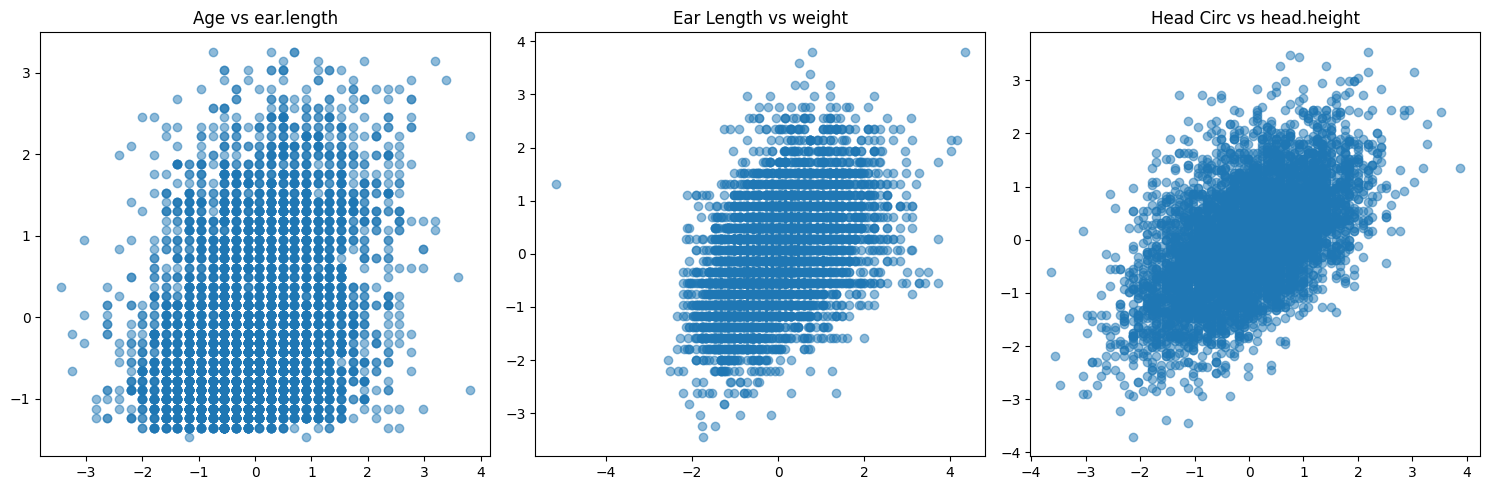

In [30]:
# Work on Data Exploration here

### Encode non-numerical features
ansur_encoder = OrdinalEncoder()
g_vals = ansur_encoder.fit_transform(ansur_df[["gender"]])
ansur_df[["gender"]] = g_vals
#categorical_columns = ansur_df.select_dtypes(include=['object']).columns
#ansur_df[categorical_columns] = ansur_encoder.fit_transform(ansur_df[categorical_columns])

## 1. Print min, max, avg
print("Summary (Min, Max, Mean):")
print(ansur_df.describe().loc[['min', 'max', 'mean']])

### Normalize all data
ansur_scaler = StandardScaler()
ansur_norm = pd.DataFrame(ansur_scaler.fit_transform(ansur_df), columns=ansur_df.columns)

## 2. Print Covariances
target_cols = ['age', 'ear.length', 'head.circumference']
print("\nCovariance Table for targets:")
print(ansur_norm[target_cols].cov())

## 3. Plot features most correlated to age, ear length and head circumference
corr_matrix = ansur_norm.corr()

# defining values 
top_age = corr_matrix['age'].sort_values(ascending=False).index[1]
top_ear = corr_matrix['ear.length'].sort_values(ascending=False).index[1]
top_head = corr_matrix['head.circumference'].sort_values(ascending=False).index[1]

# plot
plt.figure(figsize=(15, 5))

# plot 1: Age
plt.subplot(1, 3, 1)
plt.scatter(ansur_norm[top_age], ansur_norm['age'], alpha=0.5)
plt.title(f'Age vs {top_age}')

# plot 2: Ear Length
plt.subplot(1, 3, 2)
plt.scatter(ansur_norm[top_ear], ansur_norm['ear.length'], alpha=0.5)
plt.title(f'Ear Length vs {top_ear}')

# plot 3: Head Circumference
plt.subplot(1, 3, 3)
plt.scatter(ansur_norm[top_head], ansur_norm['head.circumference'], alpha=0.5)
plt.title(f'Head Circ vs {top_head}')

plt.tight_layout()
plt.show()

### Interpretation

<span style="color:hotpink;">
Does anything stand out about these graphs? Or the correlations?<br>
Are correlations symmetric? Does the feature most correlated to ear length also have ear length as its most correlated pair?<br>

<span style="color:blue;">
The graphs show that while some traits like Head Circumference and Head Height have a strong, clear relationship (forming a tight diagonal shape), Age is much more noisy and less predictable. Correlations are symmetric, meaning the relationship between Age and Ear Length is exactly the same as Ear Length and Age. However, while Ear Length might be the trait most related to Age, Ear Length itself is actually much more strongly related to Weight.
</span>

### Regression

Now, we want to create a regression model to predict `head.circumference` from the data.

From our [Week 06](https://github.com/PSAM-5020-2026S-A/WK06) notebook, we can create a regression model by following these steps:

1. Load dataset (done! 🎉)
2. Encode label features as numbers (done! ⚡️)
3. Normalize the data (done! 🍾)
4. Separate the outcome variable and the input features
5. Create a regression model using all features
6. Run model on training data and measure error
7. Plot predictions and interpret results
8. Run model on test data, measure error, plot predictions, interpret results

Training Error: 0.7584338370549019


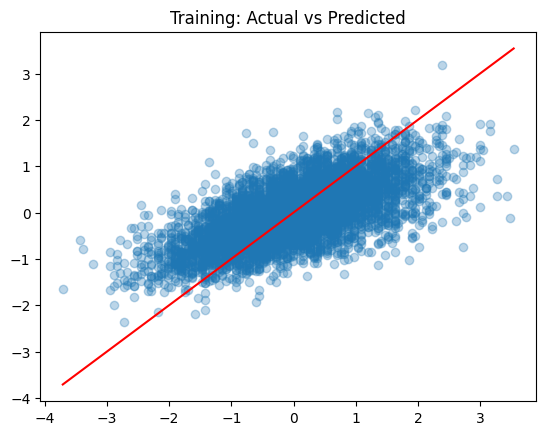

In [31]:
# Work on Regression Model here

## Separate outcome variable and input features
y = ansur_norm['head.circumference']
x = ansur_norm.drop(columns=['head.circumference'])

## Create a regression model
model = LinearRegression()
model.fit(x, y)

## Measure error on training data
y_pred = model.predict(x)
train_error = regression_error(y, y_pred)
print(f"Training Error: {train_error}")

## Plot predictions and interpret results
plt.scatter(y, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.title("Training: Actual vs Predicted")
plt.show()

In [32]:
## Load Test Data
ANSUR_TEST_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur-test.json"

ansur_test_data = object_from_json_url(ANSUR_TEST_FILE)
ansur_test_df = pd.json_normalize(ansur_test_data)

ansur_test_encoded_df = ansur_test_df.copy()

g_vals = ansur_encoder.transform(ansur_test_df[["gender"]])
ansur_test_encoded_df[["gender"]] = g_vals

ansur_test_scaled_df = ansur_scaler.transform(ansur_test_encoded_df)

ValueError: Found unknown categories ['F', 'M'] in column 0 during transform

In [ ]:
## Run model on test data

## Measure error on test data

## Plot predictions and interpret results

### Interpretation

<span style="color:hotpink;">
How well does your model perform?<br>
How could you improve it?<br>
Are there ranges of circumferences that don't get predicted well?
</span>

<span style="color:hotpink;">EDIT THIS CELL WITH ANSWER</span>